In [1]:
%load_ext autoreload
%autoreload 2

**Author:** Salvador Navas  
**Date:** 2025-06-27

In [2]:
# General stochastic generation (CoSMoS_py) — discharge, temperature, ...
from pyhydra.climate.stochastic_generation import (
    analyze_ts,
    report_ts,
    simulate_ts,
    generate_ts,
    fit_distribution,
    fit_acs,
)

# Precipitation stochastic generation (NEOPRENE NSRP)
from pyhydra.climate.stochastic_generation import NSRPModel, STNSRPModel

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Stochastic Time Series Generation

## What is stochastic generation and why use it?

A **stochastic generator** produces many synthetic time series with the same statistical properties as the observed record (same mean, variance, seasonal cycle, autocorrelation, marginal distribution). Each realisation is equally plausible — together they form an **ensemble** that spans the range of variability the system could exhibit.

### Applications
| Application | Why stochastic generation? |
|-------------|---------------------------|
| **Flood frequency analysis** | Extend a 30-year record to 10,000 synthetic years for robust T=1000 estimates |
| **Reservoir design** | Test dam operations against thousands of drought realisations, not just historical |
| **Climate impact assessment** | Generate future ensembles conditioned on climate projections |
| **Hydrological model testing** | Input ensemble to propagate uncertainty through a rainfall-runoff model |
| **Hypothesis testing** | Generate null-hypothesis samples to test whether observed trends are significant |

---

## Two complementary approaches in pyhydra

| Approach | Model | Type | Variables | Library |
|----------|-------|------|-----------|---------|
| **General** | CoSMoS (Seasonal VAR + ACTF) | Empirical / data-driven | Any hydro-meteorological variable | CoSMoS_py |
| **Precipitation** | NSRP (Neyman-Scott Rectangular Pulses) | Process-based / physics-driven | Precipitation only | NEOPRENE |

**CoSMoS:** Fits a seasonal stochastic model to any time series. Reproduces the marginal distribution per month and the lag-autocorrelation structure. No assumptions about the physical process.

**NSRP:** Encodes a physical model of storm arrival, cell structure, and rainfall intensity. Naturally reproduces wet/dry spells, inter-event statistics, and sub-daily temporal structure.

---

## When to use CoSMoS vs NSRP

| Criterion | CoSMoS | NSRP |
|-----------|--------|------|
| Variable type | Any (temperature, discharge, wind...) | Precipitation only |
| Need exact CDF reproduction | ✅ (ACTF matches empirical CDF exactly) | ❌ (parametric distribution) |
| Need realistic wet-spell structure | ❌ (no concept of storms) | ✅ (explicit storm process) |
| Need multi-site spatial correlation | ✅ (multivariate VAR model) | ✅ (ST-NSRP model) |
| Short record (< 10 years) | Unreliable | Unreliable |
| Interpretable parameters | ❌ (empirical) | ✅ (λ, μ_c, η, ξ have physical meaning) |

---
## 1. General stochastic generation — CoSMoS_py

CoSMoS implements a **seasonal VAR(p) + ACTF** (AutoCorrelation Transformation Function) model (Papalexiou & Serinaldi 2020). The workflow is:

1. Fit a **marginal distribution** per month (`fit_distribution`)
2. Fit an **autocorrelation structure** (ACS) per month — Weibull ACF: $r(h) = e^{-(h/s)^{\kappa}}$
3. Combine into a **seasonal stochastic model** (`analyze_ts`)
4. Generate synthetic realisations (`simulate_ts` / `generate_ts`)

### Workflow

| Step | Function | Key parameters | Output |
|------|----------|---------------|--------|
| 1. Fit distribution | `fit_distribution(series, dist='gengamma')` | `dist` | params dict |
| 2. Fit ACS | `fit_acs(series, lag_max=8)` | `lag_max` | 12 × `{scale, shape}` |
| 3. Seasonal model | `analyze_ts(series)` | `dist`, `acs_id` | stats dict |
| 4. Single realisation | `simulate_ts(ts_stats, from_date, to_date)` | date range | DataFrame |
| 5. Ensemble | `generate_ts(n, dist, params, acs, p0, n_series)` | `n_series` | list of arrays |

### Key parameters

| Parameter | Description | Typical value |
|-----------|-------------|--------------|
| `dist` | Marginal distribution (`gengamma`, `gamma`, `lognorm`, `norm`) | `gengamma` for discharge |
| `acs_id` | ACS model (`weibull`, `exponential`) | `weibull` |
| `lag_max` | Max lag for ACS fitting — higher = longer memory but noisier fit | 8 for daily data |
| `p0` | Zero-probability (intermittency) — set 0 for continuous variables | 0 for discharge, 0.6–0.8 for precipitation |
| `n_series` | Number of synthetic realisations in ensemble | 50–1000 |

### Synthetic data

Below we create a realistic synthetic discharge series with **seasonal mean** and **AR(1) temporal persistence** ($\rho=0.7$), representative of a mid-latitude river. This serves as the "observed" record throughout this section.

Period            : 1990-01-01 → 2019-12-31
Mean Q            : 29.83 m³/s
Std  Q            : 16.08 m³/s
Global lag-1 ACF  : 0.927  (inflated by seasonality)
Detrended lag-1   : 0.698  (AR(1) noise ρ ≈ 0.70)


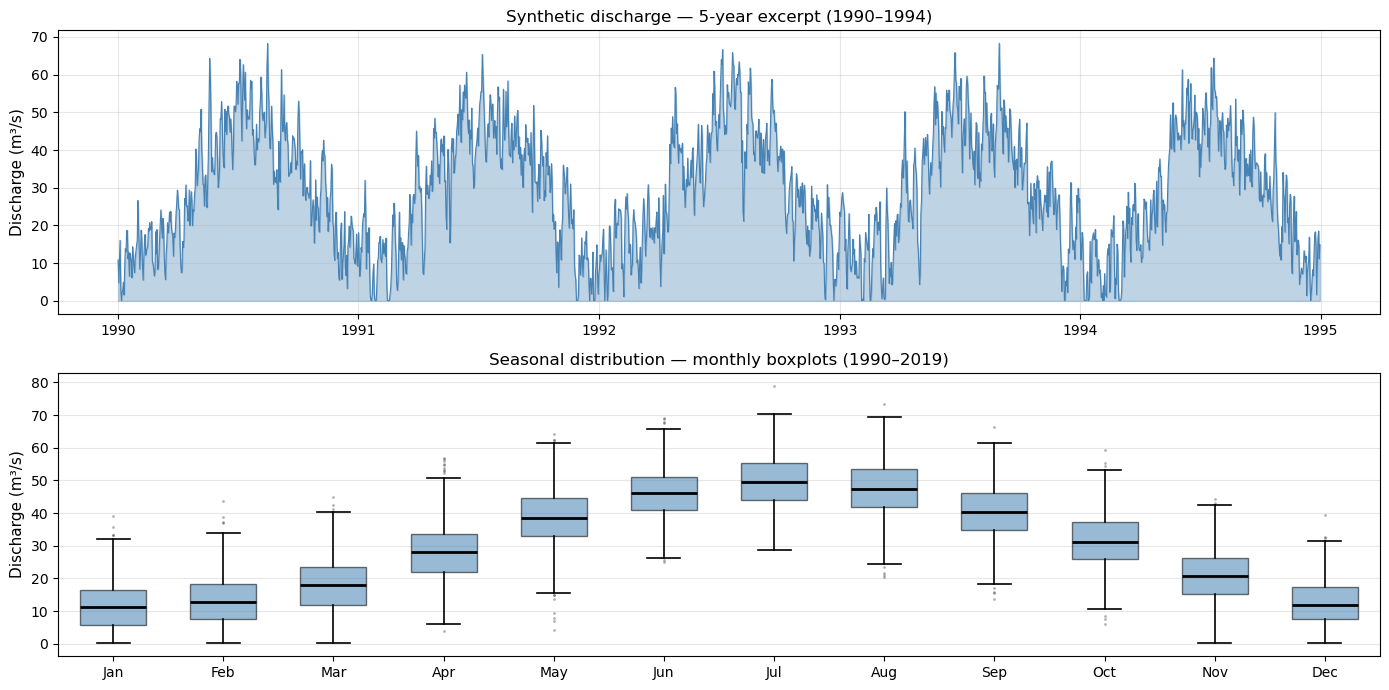

In [3]:
# Generate a synthetic 30-year daily discharge series with AR(1) persistence
rng   = np.random.default_rng(42)
dates = pd.date_range("1990-01-01", "2019-12-31", freq="D")
n     = len(dates)
doy   = np.asarray(dates.dayofyear, dtype=float)

# Seasonal mean: peaks in late summer
seasonal_mean = 30 + 20 * np.sin(2 * np.pi * (doy / 365 - 0.3))

# AR(1) noise with ρ=0.7 — realistic day-to-day persistence around the seasonal mean
rho = 0.7
eps = rng.normal(0, 8 * np.sqrt(1 - rho**2), n)
noise = np.zeros(n)
for t in range(1, n):
    noise[t] = rho * noise[t-1] + eps[t]

Q     = np.maximum(0.1, seasonal_mean + noise)
Q_obs = pd.Series(Q, index=dates, name="discharge")

# Detrended lag-1 ACF (remove seasonal mean before computing)
Q_detrend = Q_obs - Q_obs.groupby(Q_obs.index.dayofyear).transform('mean')
print(f"Period            : {dates[0].date()} → {dates[-1].date()}")
print(f"Mean Q            : {Q_obs.mean():.2f} m³/s")
print(f"Std  Q            : {Q_obs.std():.2f} m³/s")
print(f"Global lag-1 ACF  : {Q_obs.autocorr(lag=1):.3f}  (inflated by seasonality)")
print(f"Detrended lag-1   : {Q_detrend.autocorr(lag=1):.3f}  (AR(1) noise ρ ≈ 0.70)")

# ── Figure: 5-year excerpt (top) + monthly boxplots (bottom) ─────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

excerpt = Q_obs["1990":"1994"]
ax1.fill_between(excerpt.index, excerpt.values, alpha=0.35, color="steelblue")
ax1.plot(excerpt.index, excerpt.values, lw=0.8, color="steelblue")
ax1.set_ylabel("Discharge (m³/s)", fontsize=11)
ax1.set_title("Synthetic discharge — 5-year excerpt (1990–1994)", fontsize=12)
ax1.grid(alpha=0.3)

months_lbl = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_data = [Q_obs[Q_obs.index.month == m].values for m in range(1, 13)]
ax2.boxplot(month_data, patch_artist=True, widths=0.6,
            boxprops=dict(facecolor="steelblue", alpha=0.55),
            medianprops=dict(color="black", lw=2),
            whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
            flierprops=dict(marker=".", markersize=2, alpha=0.3))
ax2.set_xticklabels(months_lbl, fontsize=10)
ax2.set_ylabel("Discharge (m³/s)", fontsize=11)
ax2.set_title("Seasonal distribution — monthly boxplots (1990–2019)", fontsize=12)
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

Distribution : gengamma  (July, 930 days)
Parameters   : {'scale': np.float64(2.644593976442167), 'shape1': np.float64(33.35728369740164), 'shape2': np.float64(1.1471857701552548)}
Fit RMSE     : 0.0001



ACS fitted for 12 months
January  — model: weibull,  params: {'scale': np.float64(2.8481949975654546), 'shape': np.float64(1.2796048291433648)}
July     — model: weibull,  params: {'scale': np.float64(2.520964854490056), 'shape': np.float64(0.965504148353909)}


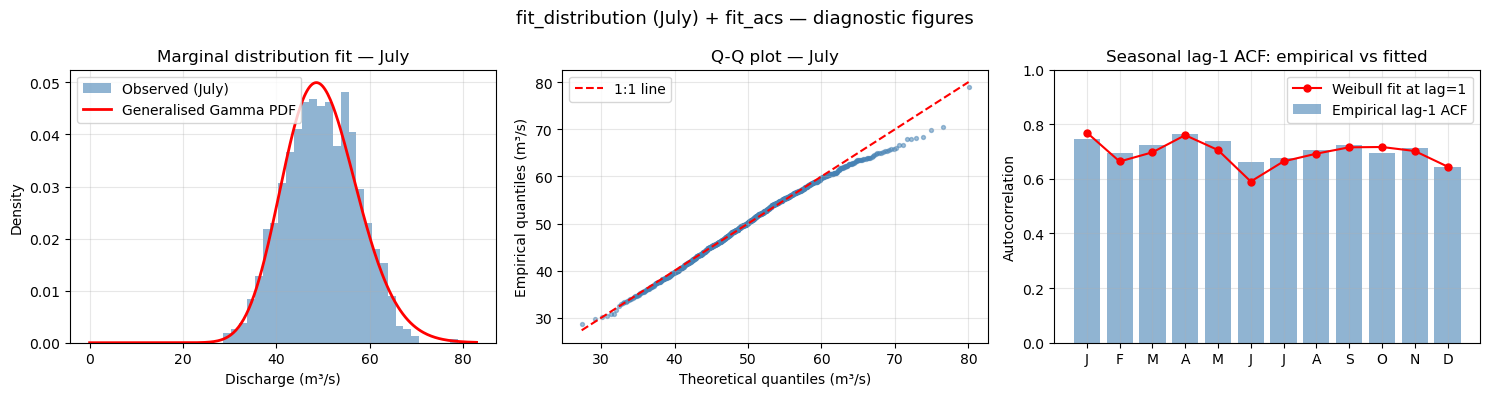

In [4]:
from scipy import stats as spstats

# fit_distribution works on a single-month slice — applying it to the full
# annual series mixes low-winter and high-summer values into a bimodal
# distribution that gengamma cannot represent cleanly.
# Here we use July (peak month) as the illustrative example.
# analyze_ts (next cell) repeats this automatically for all 12 months.
Q_july = Q_obs[Q_obs.index.month == 7]
dist = fit_distribution(Q_july, dist='gengamma')
print(f"Distribution : {dist['dist']}  (July, {len(Q_july)} days)")
print(f"Parameters   : {dist['params_dict']}")
print(f"Fit RMSE     : {dist['objective']:.4f}")

# fit_acs receives the full daily series; internally it groups by calendar month.
acs = fit_acs(Q_obs, lag_max=8)
print(f"\nACS fitted for {len(acs)} months")
print(f"January  — model: {acs[0]['acs_id']},  params: {acs[0]['params']}")
print(f"July     — model: {acs[6]['acs_id']},  params: {acs[6]['params']}")

# ── 3-panel diagnostic figure ─────────────────────────────────────────────────
p   = dist['params_dict']
rv  = spstats.gengamma(a=p['shape1']/p['shape2'], c=p['shape2'], scale=p['scale'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1 — Histogram + fitted PDF (July)
q_vals = Q_july.values
x_pdf  = np.linspace(0, q_vals.max() * 1.05, 300)
axes[0].hist(q_vals, bins=30, density=True, color="steelblue", alpha=0.6, label="Observed (July)")
axes[0].plot(x_pdf, rv.pdf(x_pdf), "r-", lw=2, label="Generalised Gamma PDF")
axes[0].set_xlabel("Discharge (m³/s)"); axes[0].set_ylabel("Density")
axes[0].set_title("Marginal distribution fit — July"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Panel 2 — Q-Q plot (July)
q_sorted = np.sort(q_vals)
probs    = (np.arange(1, len(q_sorted) + 1) - 0.5) / len(q_sorted)
q_theory = rv.ppf(probs)
axes[1].scatter(q_theory, q_sorted, s=8, alpha=0.5, color="steelblue")
lims = [min(q_theory.min(), q_sorted.min()), max(q_theory.max(), q_sorted.max())]
axes[1].plot(lims, lims, "r--", lw=1.5, label="1:1 line")
axes[1].set_xlabel("Theoretical quantiles (m³/s)"); axes[1].set_ylabel("Empirical quantiles (m³/s)")
axes[1].set_title("Q-Q plot — July"); axes[1].legend(); axes[1].grid(alpha=0.3)

# Panel 3 — Seasonal lag-1 ACF: empirical bars vs Weibull fit points
months_lbl = ["J","F","M","A","M","J","J","A","S","O","N","D"]
e_lag1 = [acs[m]['e_acs'][1] if len(acs[m]['e_acs']) > 1 else 0.0 for m in range(12)]
f_lag1 = [float(np.exp(-(1.0 / acs[m]['params']['scale']) ** acs[m]['params']['shape']))
          for m in range(12)]
axes[2].bar(range(12), e_lag1, color="steelblue", alpha=0.6, label="Empirical lag-1 ACF")
axes[2].plot(range(12), f_lag1, "ro-", ms=5, lw=1.5, label="Weibull fit at lag=1")
axes[2].set_xticks(range(12)); axes[2].set_xticklabels(months_lbl)
axes[2].set_ylabel("Autocorrelation"); axes[2].set_ylim(0, 1)
axes[2].set_title("Seasonal lag-1 ACF: empirical vs fitted"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("fit_distribution (July) + fit_acs — diagnostic figures", fontsize=13)
plt.tight_layout()
plt.show()

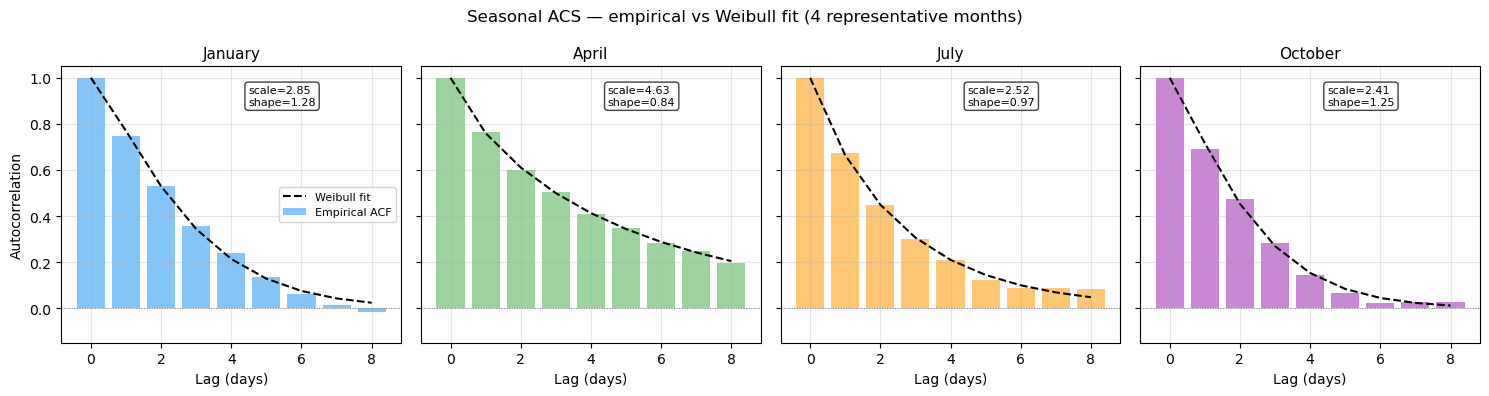

In [5]:
# Multi-lag ACF visualization: 4 representative months
months_to_plot = [0, 3, 6, 9]
month_names    = ["January", "April", "July", "October"]
colors         = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]

fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

for ax, m, name, col in zip(axes, months_to_plot, month_names, colors):
    e_acs  = acs[m]['e_acs']
    params = acs[m]['params']
    lags   = np.arange(len(e_acs))
    f_acs  = np.exp(-(lags / params['scale']) ** params['shape'])

    ax.bar(lags, e_acs, color=col, alpha=0.55, label="Empirical ACF")
    ax.plot(lags, f_acs, "k--", lw=1.5, label="Weibull fit")
    ax.axhline(0, color="gray", lw=0.7, ls=":")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Lag (days)")
    ax.set_ylim(-0.15, 1.05)
    ax.grid(alpha=0.3)
    ax.text(0.55, 0.86,
            f"scale={params['scale']:.2f}\nshape={params['shape']:.2f}",
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.75))
    if ax is axes[0]:
        ax.set_ylabel("Autocorrelation")
        ax.legend(fontsize=8)

plt.suptitle("Seasonal ACS — empirical vs Weibull fit (4 representative months)", fontsize=12)
plt.tight_layout()
plt.show()

Fitting stochastic model (analyze_ts) ...


Done.

              dist       mean        sd   p0   acs.l.2
season                                                
month_1   gengamma  11.510128  7.574565  0.0  0.746066
month_2   gengamma  13.131670  7.647988  0.0  0.694925
month_3   gengamma  17.636273  8.429115  0.0  0.725561
month_4   gengamma  28.108478  9.009652  0.0  0.763572
month_5   gengamma  38.613403  8.805122  0.0  0.739609
month_6   gengamma  46.181519  7.688429  0.0  0.663221
month_7   gengamma  49.682245  7.754884  0.0  0.675789
month_8   gengamma  47.412456  8.500051  0.0  0.706350
month_9   gengamma  40.326035  8.305442  0.0  0.725681
month_10  gengamma  31.365845  8.123243  0.0  0.693103
month_11  gengamma  20.769181  8.058084  0.0  0.713542
month_12  gengamma  12.291320  7.038899  0.0  0.644120


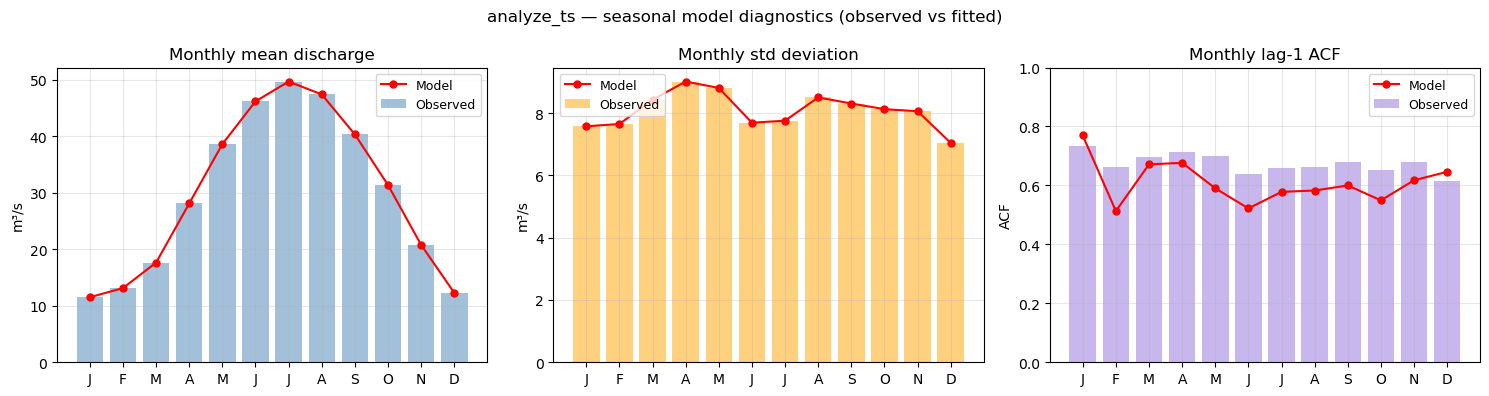

In [6]:
# Analyse the full series — fit seasonal marginals + ACS in one call
print("Fitting stochastic model (analyze_ts) ...")
ts_stats = analyze_ts(Q_obs, dist='gengamma', acs_id='weibull')
print("Done.\n")

stats_df = report_ts(ts_stats)
print(stats_df[['dist', 'mean', 'sd', 'p0', 'acs.l.2']].to_string())

# ── Seasonal diagnostics: observed vs model ───────────────────────────────────
months = list(range(1, 13))
lbl    = ["J","F","M","A","M","J","J","A","S","O","N","D"]

obs_mean = np.array([Q_obs[Q_obs.index.month == m].mean() for m in months])
obs_std  = np.array([Q_obs[Q_obs.index.month == m].std()  for m in months])
obs_acf1 = np.array([Q_obs[Q_obs.index.month == m].autocorr(lag=1) for m in months])

mod_mean = stats_df['mean'].values
mod_std  = stats_df['sd'].values
# Lag-1 ACF from Weibull fit: r(1) = exp(-(1/scale)^shape)
mod_acf1 = np.array([
    float(np.exp(-(1.0 / ts_stats['afits'][m]['params']['scale'])
                 ** ts_stats['afits'][m]['params']['shape']))
    for m in range(12)
])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [
    (axes[0], obs_mean, mod_mean, "Monthly mean discharge", "m³/s",  "steelblue"),
    (axes[1], obs_std,  mod_std,  "Monthly std deviation",  "m³/s",  "orange"),
    (axes[2], obs_acf1, mod_acf1, "Monthly lag-1 ACF",      "ACF",   "mediumpurple"),
]
for ax, obs, mod, title, ylabel, col in pairs:
    ax.bar(months, obs, color=col, alpha=0.5, label="Observed")
    ax.plot(months, mod, "ro-", ms=5, lw=1.5, label="Model")
    ax.set_xticks(months); ax.set_xticklabels(lbl)
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
axes[2].set_ylim(0, 1)

plt.suptitle("analyze_ts — seasonal model diagnostics (observed vs fitted)", fontsize=12)
plt.tight_layout()
plt.show()

Generando 30 realizaciones con el modelo estacional ...


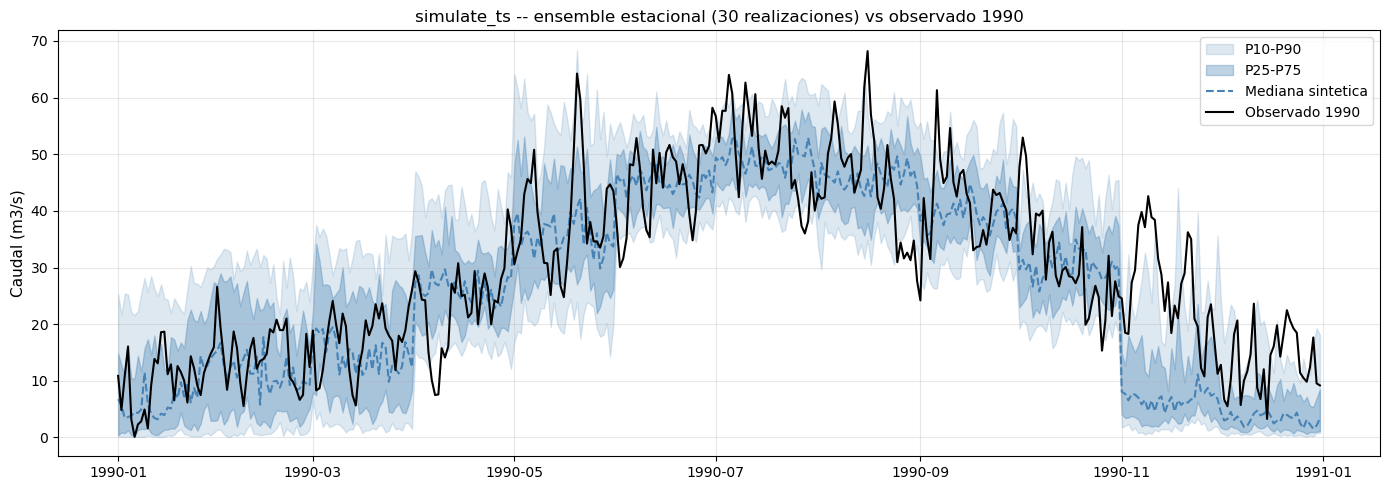

Observado  -- media: 29.83 m3/s,  std: 16.08 m3/s
Sintetico  -- media: 28.14 m3/s,  std: 18.71 m3/s
Forma del ensemble: (30, 365)  (n_sims x n_dias)


In [7]:
import warnings

# Ensemble con modelo estacional (simulate_ts).
# generate_ts ajusta una distribucion anual ignorando la estacionalidad:
# al mezclar todos los meses, la std sintetica queda ~40% mas alta que la real.
# simulate_ts usa el modelo mensual (analyze_ts calibrado) y preserva el ciclo.
N_SIM = 30
print(f'Generando {N_SIM} realizaciones con el modelo estacional ...')

sim_list = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for _ in range(N_SIM):
        r = simulate_ts(ts_stats, from_date='2021-01-01', to_date='2021-12-31')
        sim_list.append(r['value'].values[:365])

sim_arr = np.array(sim_list)          # (N_SIM, 365)
# Clip to same physical lower bound used during data generation (Q >= 0.1 m³/s).
sim_arr = np.maximum(sim_arr, 0.1)

sim_dates = pd.date_range('1990-01-01', periods=365, freq='D')
p10, p25, p50, p75, p90 = [np.percentile(sim_arr, p, axis=0) for p in [10, 25, 50, 75, 90]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(sim_dates, p10, p90, alpha=0.18, color='steelblue', label='P10-P90')
ax.fill_between(sim_dates, p25, p75, alpha=0.35, color='steelblue', label='P25-P75')
ax.plot(sim_dates, p50, lw=1.5, color='steelblue', ls='--', label='Mediana sintetica')
ax.plot(Q_obs.loc['1990'].index, Q_obs.loc['1990'].values,
        lw=1.5, color='black', label='Observado 1990')
ax.set_ylabel('Caudal (m3/s)', fontsize=11)
ax.set_title(f'simulate_ts -- ensemble estacional ({N_SIM} realizaciones) vs observado 1990',
             fontsize=12)
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Observado  -- media: {Q_obs.mean():.2f} m3/s,  std: {Q_obs.std():.2f} m3/s')
print(f'Sintetico  -- media: {sim_arr.mean():.2f} m3/s,  std: {sim_arr.std():.2f} m3/s')
print(f'Forma del ensemble: {sim_arr.shape}  (n_sims x n_dias)')

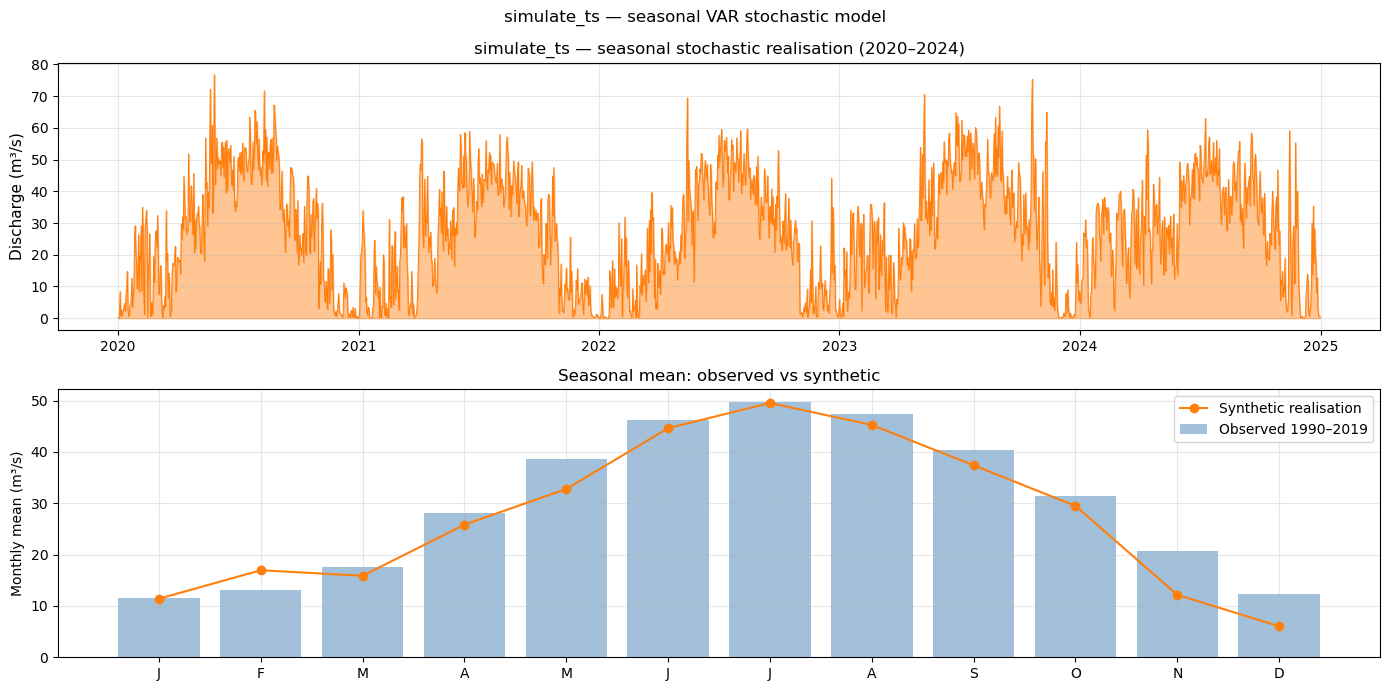

Realisation: 2020-01-01 → 2024-12-31  (1827 days)


In [8]:
# simulate_ts — single realisation from the seasonal stochastic model
# Unlike generate_ts (annual model), simulate_ts uses the seasonal VAR model
# fitted by analyze_ts, so it preserves monthly mean/variance patterns.
sim_ts = simulate_ts(ts_stats, from_date="2020-01-01", to_date="2024-12-31")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

# Top: full 5-year realisation
ax1.fill_between(sim_ts['date'], sim_ts['value'], alpha=0.45, color="C1")
ax1.plot(sim_ts['date'], sim_ts['value'], lw=0.7, color="C1")
ax1.set_ylabel("Discharge (m³/s)", fontsize=11)
ax1.set_title("simulate_ts — seasonal stochastic realisation (2020–2024)", fontsize=12)
ax1.grid(alpha=0.3)

# Bottom: seasonal mean comparison
months = list(range(1, 13))
lbl    = ["J","F","M","A","M","J","J","A","S","O","N","D"]
sim_df = sim_ts.set_index("date")
sim_monthly = [sim_df[sim_df.index.month == m]["value"].mean() for m in months]
obs_monthly = [Q_obs[Q_obs.index.month == m].mean() for m in months]

ax2.bar(months, obs_monthly, color="steelblue", alpha=0.5, label="Observed 1990–2019")
ax2.plot(months, sim_monthly, "o-", color="C1", ms=6, lw=1.5, label="Synthetic realisation")
ax2.set_xticks(months); ax2.set_xticklabels(lbl)
ax2.set_ylabel("Monthly mean (m³/s)"); ax2.set_title("Seasonal mean: observed vs synthetic")
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle("simulate_ts — seasonal VAR stochastic model", fontsize=12)
plt.tight_layout()
plt.show()
print(f"Realisation: {sim_ts['date'].iloc[0].date()} → {sim_ts['date'].iloc[-1].date()}  ({len(sim_ts)} days)")

---
## 2. Precipitation — NSRP Model (NEOPRENE)

The **Neyman-Scott Rectangular Pulses Model (NSRPM)** is a **process-based** stochastic model for precipitation. Unlike the empirical CoSMoS approach, it encodes a physical description of the rainfall generation process.

### Physical process

```
Storm arrivals  ~ Poisson(λ)
  └─ Each storm spawns cells ~ Poisson(μ_c)
       └─ Each cell has:
            ├─ Duration L  ~ Exponential(η)      [hours]
            ├─ Intensity X ~ Exponential(ξ)      [mm/h]
            └─ Lag Δt      ~ Exponential(β)  from storm origin
```

Rainfall at time $t$ = sum of intensities of all active cells overlapping $t$.

### Calibration via PSO

The NSRP model is calibrated by **Particle Swarm Optimisation (PSO)**, minimising a weighted distance between observed and modelled statistics for each month:

| Target statistic | Symbol | Hydrological relevance |
|-----------------|--------|------------------------|
| Mean | $\mu$ | Preserves total rainfall volume |
| Variance | $\sigma^2$ | Preserves inter-event variability |
| Lag-1 covariance | $\text{Cov}(1)$ | Preserves short-range persistence |
| Probability dry | $p_0$ | Preserves dry-day intermittency |

### Model variants

| Class | Model | Sites | Input |
|-------|-------|-------|-------|
| `NSRPModel` | NSRPM | Single-site | `pd.Series` |
| `STNSRPModel` | ST-NSRPM | Multi-site spatial | `pd.DataFrame` |

> **Requires NEOPRENE:** `pip install NEOPRENE`  
> Reference: Rodríguez-Iturbe et al. (1987); Cowpertwait (1994); IH Cantabria

In [9]:
# Generate a synthetic 30-year daily precipitation series using a Markov chain.
#
# Why Markov chain instead of independent Bernoulli draws?
# NSRP models precipitation as clustered storms: each storm spawns a Poisson number
# of cells, each with exponential duration and intensity. The sequence has multi-day
# wet spells separated by dry gaps — a 2-state Markov structure matches this better
# than independent Bernoulli draws, which have no wet-spell memory.
#
# Wet-day fraction target: ~0.50.  NSRP with daily aggregation overestimates wet
# fraction by ~0.15-0.20 relative to the Cowpertwait formula due to cell spill-over
# across midnight.  Targeting 0.50 keeps the simulation result in a plausible range.
# For wet fraction < 0.40, NSRP at daily resolution cannot reproduce the dry-day
# statistics reliably — use hourly NSRP or CoSMoS instead.
rng_p   = np.random.default_rng(42)
dates_p = pd.date_range("1990-01-01", "2019-12-31", freq="D")
n_p     = len(dates_p)
doy_p   = np.asarray(dates_p.dayofyear, dtype=float)

# Seasonal dry->wet probability: peaks in spring/autumn (Mediterranean-type)
p_d2w = 0.35 + 0.08 * np.sin(2 * np.pi * (doy_p / 365 - 0.1))
p_w2d = 0.35  # mean storm duration ~2.9 days -> wet fraction ~0.50

state = 0
wet   = np.zeros(n_p, dtype=bool)
for t in range(n_p):
    if state == 0 and rng_p.random() < p_d2w[t]:
        state = 1
    elif state == 1 and rng_p.random() < p_w2d:
        state = 0
    wet[t] = bool(state)

prec  = np.where(wet, rng_p.exponential(5, n_p), 0.0)
P_obs = pd.Series(prec, index=dates_p, name="precipitation")

print(f"Wet-day fraction : {(P_obs > 0).mean():.2f}")
print(f"Mean             : {P_obs.mean():.2f} mm/day")
print(f"Std              : {P_obs.std():.2f} mm/day")
print(f"Max              : {P_obs.max():.1f} mm")

Wet-day fraction : 0.50
Mean             : 2.49 mm/day
Std              : 4.35 mm/day
Max              : 52.5 mm


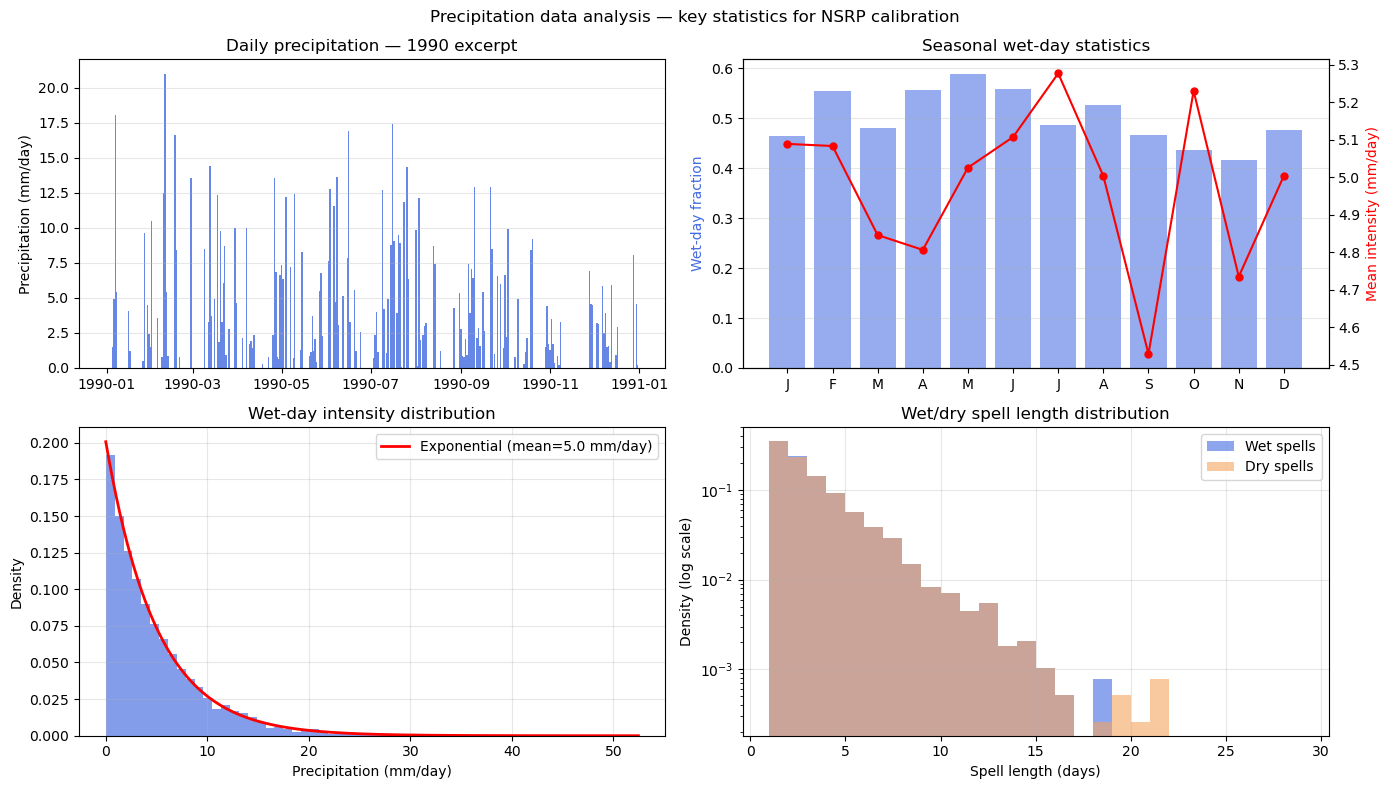

Wet-day fraction : 0.50
Mean intensity   : 4.98 mm/day
Mean wet spell   : 2.8 days
Mean dry spell   : 2.8 days


In [10]:
# Exploratory analysis of the precipitation series — 4-panel figure
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Panel 1: Daily time series (1-year excerpt)
excerpt_p = P_obs["1990"]
axes[0, 0].bar(excerpt_p.index, excerpt_p.values, width=1, color="royalblue", alpha=0.8)
axes[0, 0].set_ylabel("Precipitation (mm/day)")
axes[0, 0].set_title("Daily precipitation — 1990 excerpt")
axes[0, 0].grid(alpha=0.3, axis="y")

# Panel 2: Monthly wet-day fraction + mean wet-day intensity
months_p   = list(range(1, 13))
lbl_p      = ["J","F","M","A","M","J","J","A","S","O","N","D"]
wet_frac   = [(P_obs[P_obs.index.month == m] > 0).mean() for m in months_p]
mean_int   = [P_obs[(P_obs.index.month == m) & (P_obs > 0)].mean() for m in months_p]

ax2a = axes[0, 1]
ax2b = ax2a.twinx()
ax2a.bar(months_p, wet_frac, color="royalblue", alpha=0.55, label="Wet-day fraction")
ax2b.plot(months_p, mean_int, "ro-", ms=5, lw=1.5, label="Mean wet-day intensity")
ax2a.set_xticks(months_p); ax2a.set_xticklabels(lbl_p)
ax2a.set_ylabel("Wet-day fraction", color="royalblue")
ax2b.set_ylabel("Mean intensity (mm/day)", color="red")
ax2a.set_title("Seasonal wet-day statistics")
ax2a.grid(alpha=0.3, axis="y")

# Panel 3: Wet-day intensity distribution
wet_vals  = P_obs[P_obs > 0].values
loc_e, sc_e = spstats.expon.fit(wet_vals, floc=0)
x_exp     = np.linspace(0, wet_vals.max(), 300)
axes[1, 0].hist(wet_vals, bins=60, color="royalblue", alpha=0.65, density=True)
axes[1, 0].plot(x_exp, spstats.expon.pdf(x_exp, scale=sc_e), "r-", lw=2,
                label=f"Exponential (mean={sc_e:.1f} mm/day)")
axes[1, 0].set_xlabel("Precipitation (mm/day)"); axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title("Wet-day intensity distribution"); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# Panel 4: Wet/dry spell length distribution
def _spell_lengths(series, wet):
    out, count = [], 0
    in_spell = (series.iloc[0] > 0) == wet
    for v in series.values:
        same = (v > 0) == wet
        if same == in_spell:
            count += 1
        else:
            if count > 0:
                out.append(count)
            in_spell, count = same, 1
    if count > 0:
        out.append(count)
    return np.array(out)

wet_spells = _spell_lengths(P_obs, True)
dry_spells = _spell_lengths(P_obs, False)
axes[1, 1].hist(wet_spells, bins=range(1, 20), color="royalblue", alpha=0.6, density=True, label="Wet spells")
axes[1, 1].hist(dry_spells, bins=range(1, 30), color="sandybrown", alpha=0.6, density=True, label="Dry spells")
axes[1, 1].set_xlabel("Spell length (days)"); axes[1, 1].set_ylabel("Density (log scale)")
axes[1, 1].set_yscale("log"); axes[1, 1].set_title("Wet/dry spell length distribution")
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

plt.suptitle("Precipitation data analysis — key statistics for NSRP calibration", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Wet-day fraction : {(P_obs > 0).mean():.2f}")
print(f"Mean intensity   : {P_obs[P_obs > 0].mean():.2f} mm/day")
print(f"Mean wet spell   : {wet_spells.mean():.1f} days")
print(f"Mean dry spell   : {dry_spells.mean():.1f} days")

In [11]:
try:
    # NSRPModel — default statistics: mean, var_1, autocorr_1_1, fih_1
    # Bounds are tuned for daily data with low wet fraction: see _default_model_bounds().
    # n_bees=100 is a practical compromise; official NEOPRENE examples use 1000.
    model = NSRPModel(
        temporal_resolution='d',
        seasonality='monthly',
        n_iterations=100,
        n_bees=100,
    )
    print(model)
    print(f"Statistics : {model.statistics_name}")
    print(f"Weights    : {model.weights}")
    print(f"Bounds     : {model.model_bounds}")
except Exception as e:
    print(f"NSRPModel error: {e}")

Statistics : ['mean', 'var_1', 'autocorr_1_1', 'fih_1']
Weights    : [1.0, 1.0, 1.0, 1.0]
Bounds     : {'time_between_storms': [12.0, 500.0], 'number_storm_cells': [2.0, 20.0], 'cell_duration': [0.5, 8.0], 'cell_intensity': [0.1, 500.0], 'storm_cell_displacement': [10.0, 48.0]}


Observed statistics — NSRP calibration targets:
                      1          2          3          4          5          6          7          8          9         10         11         12
mean           2.363933   2.820814   2.329197   2.670326    2.95596   2.854432   2.564778   2.636218   2.113552   2.277744   1.967746     2.3838
var_1         20.551866  21.629415  16.501666  16.878757  20.894622  19.694005  20.401775  20.670227  15.314028  16.566435  14.769511  21.996736
autocorr_1_1   0.062883   0.056578   0.086105   0.078114    0.04262    0.03546   0.048315   0.081203   0.136924   0.064117   0.102335   0.099808
fih_1          0.541935   0.459268   0.533333   0.451111   0.419355   0.454444   0.525806   0.484946       0.54   0.570968   0.593333   0.536559


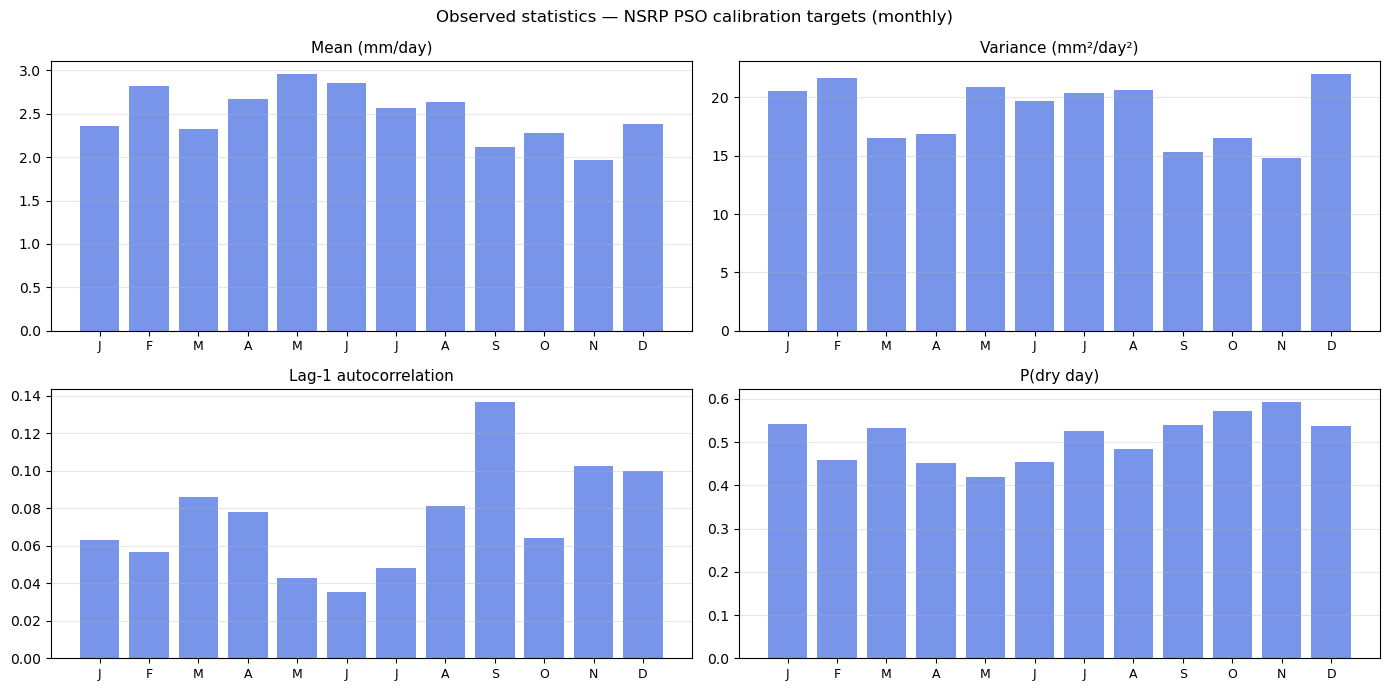

In [12]:
import warnings

try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        obs_stats = model.compute_statistics(P_obs)

    df_obs = obs_stats.statististics_dataframe
    months = list(range(1, 13))
    lbl    = ["J","F","M","A","M","J","J","A","S","O","N","D"]
    stat_labels = {
        "mean":         "Mean (mm/day)",
        "var_1":        "Variance (mm²/day²)",
        "autocorr_1_1": "Lag-1 autocorrelation",
        "fih_1":        "P(dry day)",
    }

    print("Observed statistics — NSRP calibration targets:")
    print(df_obs.round(3).to_string())

    # ── 4-panel: observed statistics per month (= PSO calibration targets) ────
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    for ax, (stat, label) in zip(axes.flat, stat_labels.items()):
        vals = df_obs.loc[stat].values.astype(float)
        ax.bar(months, vals, color="royalblue", alpha=0.7)
        ax.set_xticks(months); ax.set_xticklabels(lbl, fontsize=9)
        ax.set_title(label, fontsize=11); ax.grid(alpha=0.3, axis="y")

    plt.suptitle("Observed statistics — NSRP PSO calibration targets (monthly)", fontsize=12)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"compute_statistics not available: {e}")



################################################################################
Adjustment of parameters using the Particle Swarm Optimization (PSO)




Calibration done.

Fitted NSRP parameters (per month):
                 1          2         3          4          5          6          7          8          9         10         11        12
landa     0.630251   0.765571  0.452895     0.7075   0.891481   0.896361   0.723849   0.486621   0.219098   0.605281    0.45718   0.43477
ipsilon        2.0        2.0       2.0        2.0        2.0        2.0        2.0   3.390516   5.018818        2.0   4.872376       2.0
eta      12.111412  13.031896  9.421976  13.313136  15.028515  16.200755  13.554044  14.738825  14.465891  12.860542  23.329893  9.007162
xi           0.048      0.048     0.048      0.048      0.048      0.048      0.048      0.048      0.048      0.048      0.048     0.048
betha          2.4        2.4  2.112917        0.5        2.4        2.4        2.4   2.392409   1.624714        2.4        2.4  2.243378


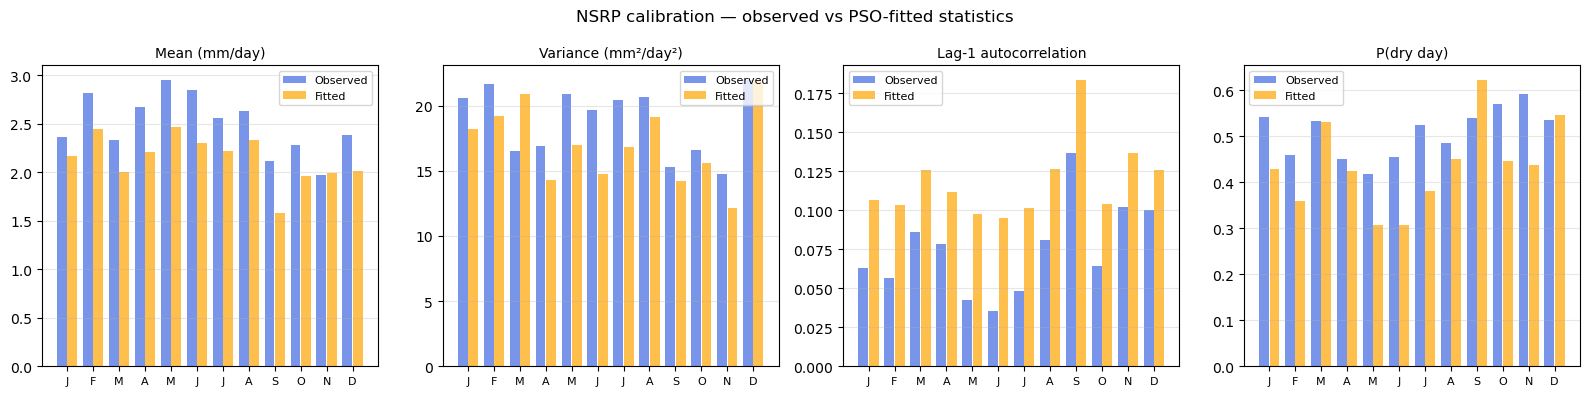

In [13]:
import warnings

try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = model.calibrate(P_obs, verbose=False)

    print("Calibration done.\n")
    print("Fitted NSRP parameters (per month):")
    print(result.Fitted_parameters.round(4).to_string())

    # ── Observed vs fitted statistics per month ───────────────────────────────
    df_real = result.statististics_Real   # DataFrame: rows=stats, cols=months
    df_fit  = result.statististics_Fit    # DataFrame: rows=stats, cols=months
    months  = list(range(1, len(df_fit.columns) + 1))
    lbl     = ["J","F","M","A","M","J","J","A","S","O","N","D"][:len(months)]
    stat_labels = {
        "mean":         "Mean (mm/day)",
        "var_1":        "Variance (mm²/day²)",
        "autocorr_1_1": "Lag-1 autocorrelation",
        "fih_1":        "P(dry day)",
    }

    n   = len(df_fit.index)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    x = np.arange(len(months))

    for ax, stat in zip(axes, df_fit.index):
        obs_v = df_real.loc[stat].values.astype(float)
        fit_v = df_fit.loc[stat].values.astype(float)
        ax.bar(x - 0.2, obs_v, 0.38, color="royalblue", alpha=0.7, label="Observed")
        ax.bar(x + 0.2, fit_v, 0.38, color="orange",    alpha=0.7, label="Fitted")
        ax.set_xticks(x); ax.set_xticklabels(lbl, fontsize=8)
        ax.set_title(stat_labels.get(stat, stat), fontsize=10)
        ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

    plt.suptitle("NSRP calibration — observed vs PSO-fitted statistics", fontsize=12)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Calibration not available: {e}")
    print("  Install NEOPRENE:  pip install NEOPRENE")



################################################################################
Synthetic simulation




Total cumulative rainfall - Analytical estimation =        76275.03
Total cumulative rainfall -             Simulated =        76221.06


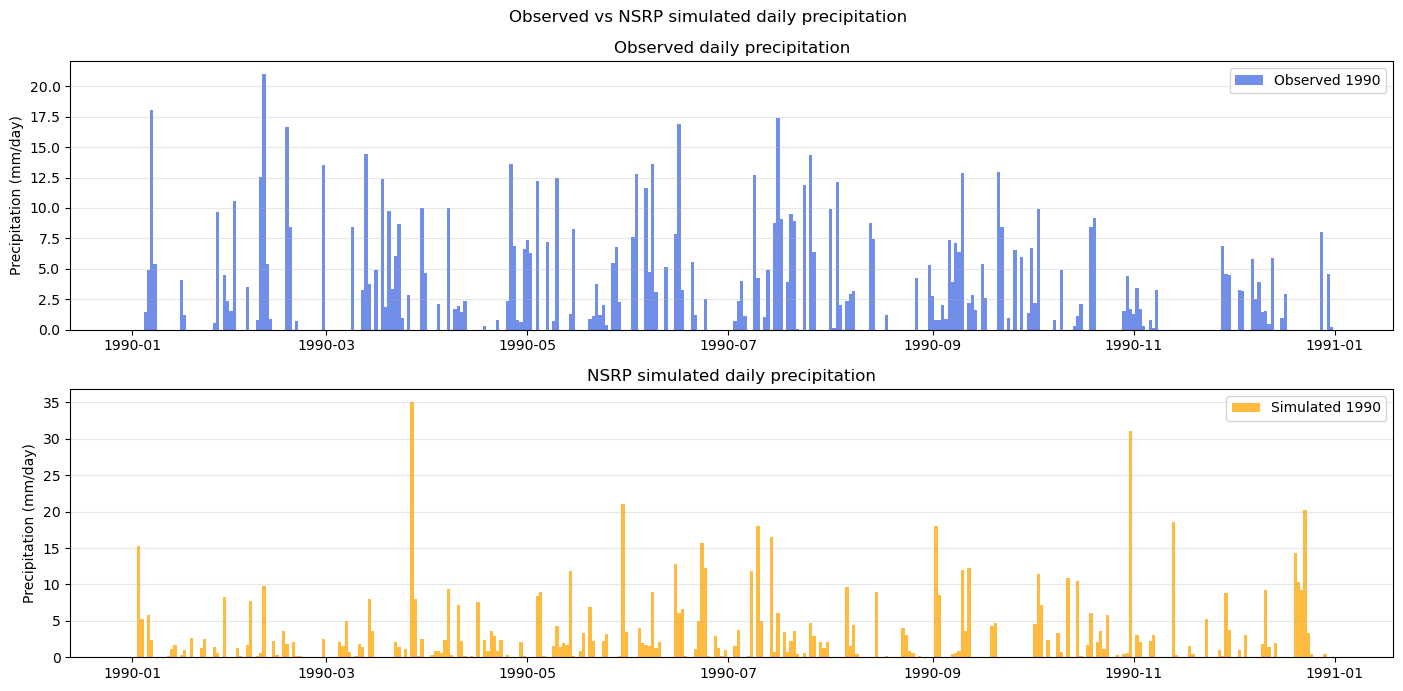

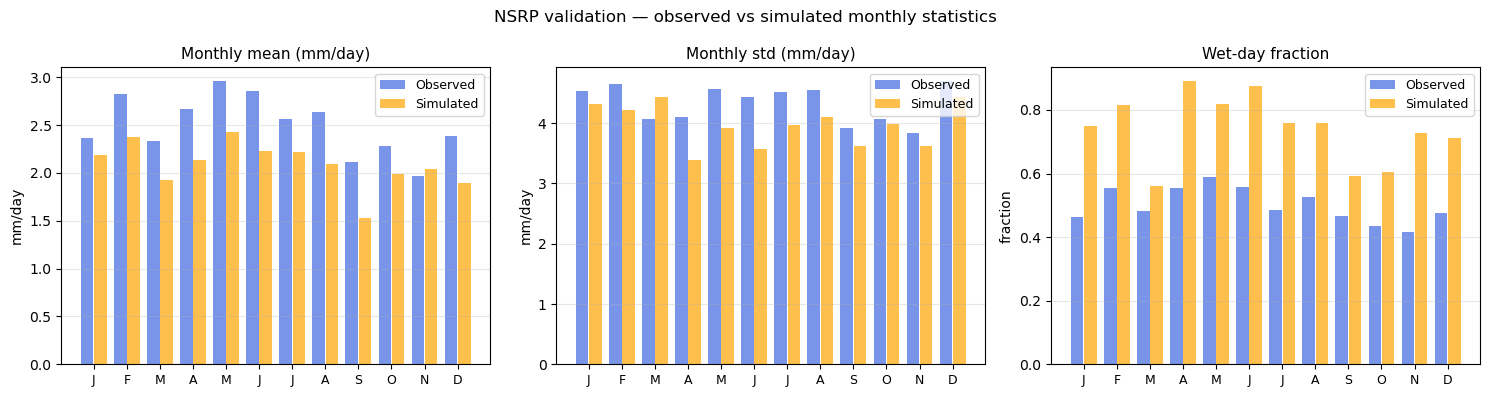

Simulated : 1990-01-01 → 2090-01-01  (36526 days)
Mean  — observed: 2.49 mm/day   simulated: 2.09 mm/day
Wet % — observed: 0.50        simulated: 0.74


In [14]:
import warnings

try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sim_result = model.simulate(year_ini=1990, year_fin=2090)

    df_daily = sim_result.Daily_Simulation.copy()
    if hasattr(df_daily.index, 'to_timestamp'):
        df_daily.index = df_daily.index.to_timestamp()
    else:
        df_daily.index = pd.to_datetime(df_daily.index)

    rain_col = df_daily.columns[0]
    sim_s    = df_daily[rain_col]

    # ── Figure 1: time series — observed 1990 vs simulated first year ─────────
    obs_1yr  = P_obs.loc[P_obs.index.year == 1990]
    sim_1yr  = sim_s.loc[sim_s.index.year == sim_s.index.year[0]]

    fig, axes = plt.subplots(2, 1, figsize=(14, 7))
    axes[0].bar(obs_1yr.index, obs_1yr.values, width=1, color="royalblue", alpha=0.75, label="Observed 1990")
    axes[0].set_ylabel("Precipitation (mm/day)"); axes[0].set_title("Observed daily precipitation")
    axes[0].legend(); axes[0].grid(alpha=0.3, axis="y")

    axes[1].bar(sim_1yr.index, sim_1yr.values, width=1, color="orange", alpha=0.75,
                label=f"Simulated {sim_1yr.index.year[0]}")
    axes[1].set_ylabel("Precipitation (mm/day)"); axes[1].set_title("NSRP simulated daily precipitation")
    axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")

    plt.suptitle("Observed vs NSRP simulated daily precipitation", fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Figure 2: monthly statistics — observed vs simulated ──────────────────
    months = list(range(1, 13))
    lbl    = ["J","F","M","A","M","J","J","A","S","O","N","D"]
    x      = np.arange(12)

    obs_mean = [P_obs[P_obs.index.month == m].mean() for m in months]
    obs_std  = [P_obs[P_obs.index.month == m].std()  for m in months]
    obs_wet  = [(P_obs[P_obs.index.month == m] > 0).mean() for m in months]
    sim_mean = [sim_s[sim_s.index.month == m].mean() for m in months]
    sim_std  = [sim_s[sim_s.index.month == m].std()  for m in months]
    sim_wet  = [(sim_s[sim_s.index.month == m] > 0).mean() for m in months]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, obs, sim, title, ylabel in zip(
        axes,
        [obs_mean, obs_std, obs_wet],
        [sim_mean, sim_std, sim_wet],
        ["Monthly mean (mm/day)", "Monthly std (mm/day)", "Wet-day fraction"],
        ["mm/day", "mm/day", "fraction"],
    ):
        ax.bar(x - 0.2, obs, 0.38, color="royalblue", alpha=0.7, label="Observed")
        ax.bar(x + 0.2, sim, 0.38, color="orange",    alpha=0.7, label="Simulated")
        ax.set_xticks(x); ax.set_xticklabels(lbl, fontsize=9)
        ax.set_title(title, fontsize=11); ax.set_ylabel(ylabel)
        ax.legend(fontsize=9); ax.grid(alpha=0.3, axis="y")

    plt.suptitle("NSRP validation — observed vs simulated monthly statistics", fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"Simulated : {sim_s.index[0].date()} → {sim_s.index[-1].date()}  ({len(sim_s)} days)")
    print(f"Mean  — observed: {P_obs.mean():.2f} mm/day   simulated: {sim_s.mean():.2f} mm/day")
    print(f"Wet % — observed: {(P_obs>0).mean():.2f}        simulated: {(sim_s>0).mean():.2f}")

except Exception as e:
    print(f"Simulation not available: {e}")
    print("  Run calibration first.")

---
## 3. Multi-site precipitation — ST-NSRP Model

The **Spatial-Temporal NSRPM (ST-NSRPM)** extends the single-site model to simultaneously reproduce precipitation at multiple rain gauges, including their **spatial cross-correlations**.

### When to use NSRP vs ST-NSRP

| Criterion | `NSRPModel` | `STNSRPModel` |
|-----------|------------|--------------|
| Number of sites | 1 | 2 or more |
| Spatial correlation | Not modelled | Reproduced |
| Use case | Catchment-integrated rainfall | Spatially distributed model forcing |
| Input | `pd.Series` | `pd.DataFrame` (dates × stations) |
| Calibration time | Low | Higher (cross-covariance per month) |

### API

```python
# Multi-site input: columns = rain gauge stations, index = dates
df_multisite = pd.DataFrame({
    "station_A": prec_A,
    "station_B": prec_B,
}, index=dates)

st_model = STNSRPModel(temporal_resolution='d', seasonality='monthly')
st_model.fit(df_multisite)          # PSO calibration per month
sim_result = st_model.simulate(year_ini=1990, year_fin=2090)
df_daily = sim_result.Daily_Simulation   # DataFrame: columns = stations
```

> **Spatial cross-correlation** is reproduced by fitting the inter-site covariance structure during PSO calibration — the model ensures that storms generate correlated wet/dry sequences across all stations simultaneously.

Station A — mean: 2.49 mm/day,  wet%: 0.50
Station B — mean: 3.32 mm/day,  wet%: 0.41
Annual cross-correlation A–B: 0.207


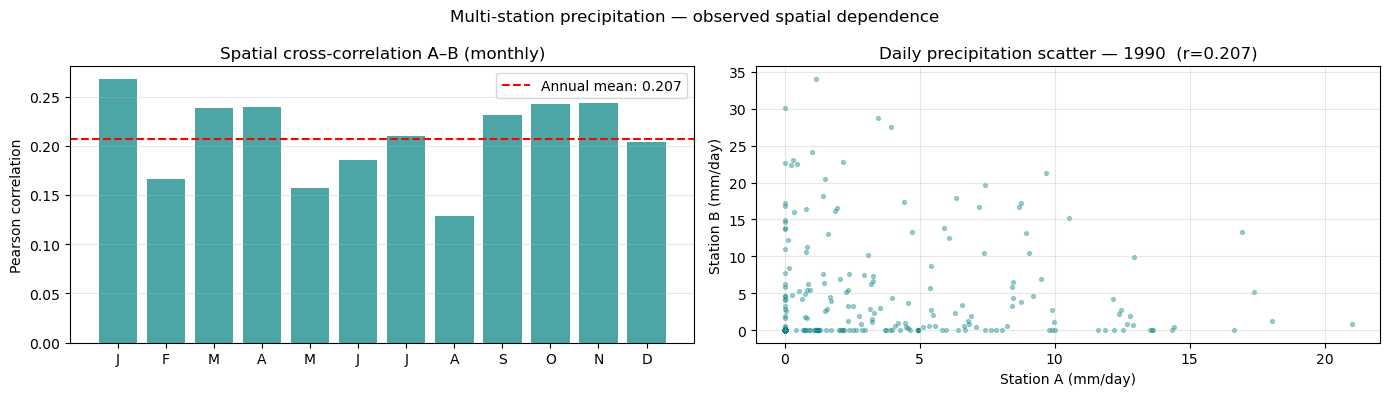



################################################################################
Adjustment of parameters using the Particle Swarm Optimization (PSO)





ST-NSRP calibration done.

Fitted parameters (per month):
              1        2        3        4        5        6        7        8        9       10       11       12
landa     0.5179   0.6461   0.5405   0.6346   0.7025   0.6306   0.5382   0.6098   0.4721   0.493   0.4664   0.4750
ipsilon   2.0000   2.0000   2.0000   2.0000   2.0000   2.0000   2.0000   2.0000   2.0148   2.000   2.0000   2.0000
eta      48.0000  48.0000  48.0000  48.0000  48.0000  48.0000  48.0000  48.0000  48.0000  48.000  48.0000  48.0000
betha     2.4000   0.5000   2.4000   2.4000   0.5000   2.4000   2.4000   0.5000   1.3428   2.400   2.4000   0.8681
fi_may    1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   1.000   1.0000   1.0000


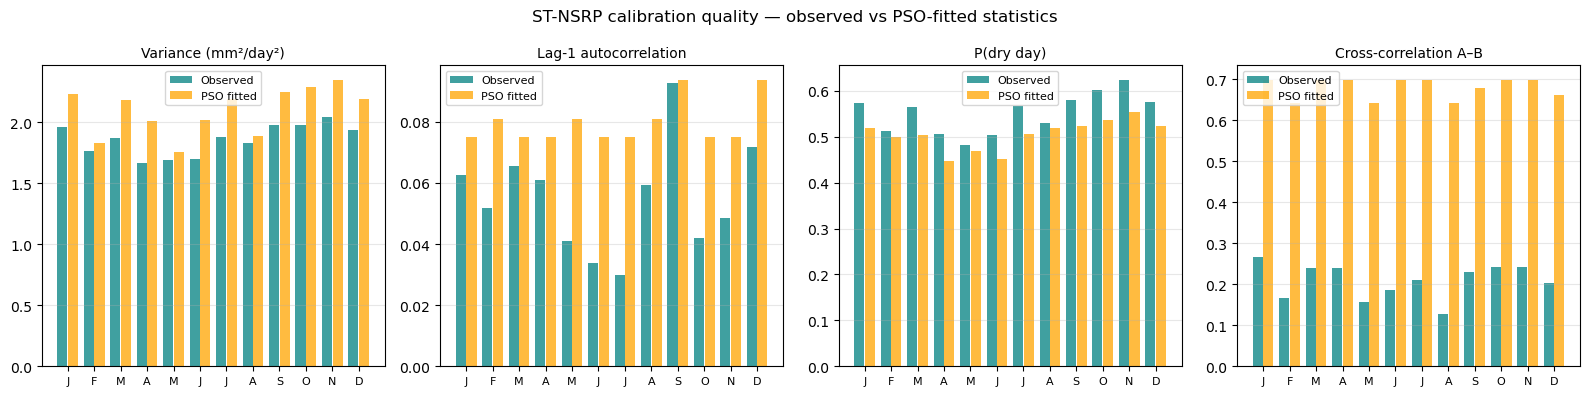



################################################################################
Synthetic simulation




Simulation corners: 
 xp:[np.float64(-3.8352454973937014), np.float64(-3.6647545026062986), np.float64(-3.6647545026062986), np.float64(-3.8352454973937014)]
 yp:[np.float64(43.264754502606294), np.float64(43.264754502606294), np.float64(43.4352454973937), np.float64(43.4352454973937)]
Simulation area (km²):261.71062494005895
Cells per storm per km²: 
[0.31830989 0.31830989 0.31830989 0.31830989 0.31830989 0.31830989
 0.31830989 0.31830989 0.32066672 0.31830989 0.31830989 0.31830989]
Cells per storm in my simulation area: 
[83.30507924 83.30507924 83.30507924 83.30507924 83.30507924 83.30507924
 83.30507924 83.30507924 83.92188838 83.30507924 83.30507924 83.30507924]
Number of storms 323 for the months 1
Number of rain cells per storm 84.49226006191951


  0%|          | 0/323 [00:00<?, ?it/s]

  4%|▍         | 13/323 [00:00<00:02, 128.67it/s]

  8%|▊         | 26/323 [00:00<00:02, 129.41it/s]

...

 83%|████████▎ | 254/305 [00:01<00:00, 135.27it/s]

 88%|████████▊ | 268/305 [00:01<00:00, 135.72it/s]

 92%|█████████▏| 282/305 [00:02<00:00, 134.30it/s]

 97%|█████████▋| 296/305 [00:02<00:00, 132.88it/s]

100%|██████████| 305/305 [00:02<00:00, 133.93it/s]

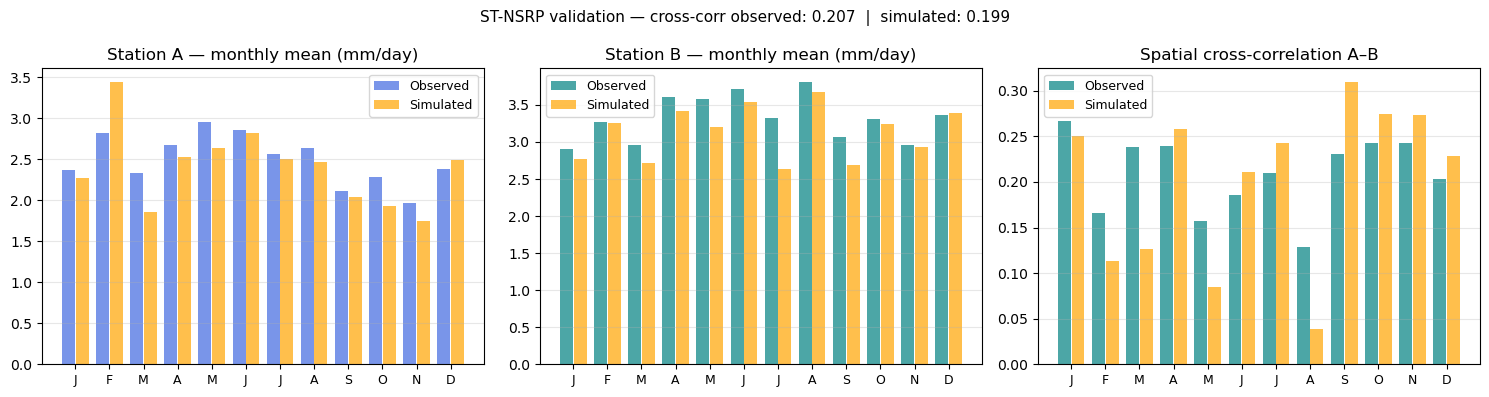


Cross-correlation — observed: 0.207   simulated: 0.199


In [15]:
import warnings

# ── 1. Generate 2 spatially-correlated precipitation stations ─────────────────
rng_st  = np.random.default_rng(99)
wet_A   = P_obs.values > 0

shared  = rng_st.random(len(P_obs)) < 0.70
wet_B   = (wet_A & shared) | ((~wet_A) & (rng_st.random(len(P_obs)) < 0.12))
prec_B  = np.where(wet_B, rng_st.exponential(8, len(P_obs)), 0.0)

P_B   = pd.Series(prec_B, index=P_obs.index, name="B")
df_st = pd.DataFrame({"A": P_obs.values, "B": prec_B}, index=P_obs.index)

attrs = pd.DataFrame({
    "ID":        ["A",    "B"],
    "Lon":       [-3.70,  -3.80],
    "Lat":       [43.30,  43.40],
    "elevation": [10.0,   50.0],
})

months = list(range(1, 13))
lbl    = ["J","F","M","A","M","J","J","A","S","O","N","D"]

obs_xcorr = df_st["A"].corr(df_st["B"])
print(f"Station A — mean: {P_obs.mean():.2f} mm/day,  wet%: {(P_obs>0).mean():.2f}")
print(f"Station B — mean: {P_B.mean():.2f} mm/day,  wet%: {(P_B>0).mean():.2f}")
print(f"Annual cross-correlation A–B: {obs_xcorr:.3f}")

# ── 2. Seasonal cross-correlation + scatter ───────────────────────────────────
xcorr_m = [df_st[df_st.index.month == m]["A"].corr(df_st[df_st.index.month == m]["B"])
           for m in months]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.bar(months, xcorr_m, color="teal", alpha=0.7)
ax1.axhline(obs_xcorr, color="red", ls="--", lw=1.5, label=f"Annual mean: {obs_xcorr:.3f}")
ax1.set_xticks(months); ax1.set_xticklabels(lbl)
ax1.set_ylabel("Pearson correlation"); ax1.set_title("Spatial cross-correlation A–B (monthly)")
ax1.legend(); ax1.grid(alpha=0.3, axis="y")

yr = "1990"
ax2.scatter(df_st.loc[yr, "A"], df_st.loc[yr, "B"], alpha=0.35, s=8, color="teal")
ax2.set_xlabel("Station A (mm/day)"); ax2.set_ylabel("Station B (mm/day)")
ax2.set_title(f"Daily precipitation scatter — {yr}  (r={obs_xcorr:.3f})")
ax2.grid(alpha=0.3)
plt.suptitle("Multi-station precipitation — observed spatial dependence", fontsize=12)
plt.tight_layout(); plt.show()

# ── 3. Calibrate STNSRPModel ──────────────────────────────────────────────────
# STNSRP forbids 'mean'; requires 'crosscorr_h'.
# n_iterations=100, n_bees=100 → 10000 PSO evaluations per month.
try:
    st_model = STNSRPModel(
        temporal_resolution='d',
        seasonality='monthly',
        statistics=['var_1', 'autocorr_1_1', 'fih_1', 'crosscorr_1'],
        n_iterations=100,
        n_bees=100,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result_st = st_model.fit(df_st, attributes=attrs, verbose=False)

    print("\nST-NSRP calibration done.")
    print("\nFitted parameters (per month):")
    print(result_st.Fitted_parameters.round(4).to_string())

    # ── 4. Calibration quality: observed vs PSO-fitted statistics ─────────────
    # statististics_Real: {month_int: DataFrame(rows=stats, cols=stations)}
    # statististics_Fit:  {month_str: DataFrame(rows=stats, cols=stations)}
    # crosscorr_Real/Fit: {'crosscorr_1': {month_int: DataFrame(dist, cross_corr)}}
    point_stats = ['var_1', 'autocorr_1_1', 'fih_1']
    stat_labels = {
        'var_1':        'Variance (mm²/day²)',
        'autocorr_1_1': 'Lag-1 autocorrelation',
        'fih_1':        'P(dry day)',
        'crosscorr_1':  'Cross-correlation A–B',
    }

    # Average across stations for point statistics; use mean cross-corr for spatial
    def _monthly_stat(result, stat, key_type='int'):
        vals = []
        for m in range(1, 13):
            key = m if key_type == 'int' else str(m)
            df  = result[key]
            vals.append(float(df.loc[stat].mean()))  # average over stations
        return np.array(vals)

    obs_var  = _monthly_stat(result_st.statististics_Real, 'var_1',        'int')
    obs_acf  = _monthly_stat(result_st.statististics_Real, 'autocorr_1_1', 'int')
    obs_fih  = _monthly_stat(result_st.statististics_Real, 'fih_1',        'int')
    fit_var  = _monthly_stat(result_st.statististics_Fit,  'var_1',        'str')
    fit_acf  = _monthly_stat(result_st.statististics_Fit,  'autocorr_1_1', 'str')
    fit_fih  = _monthly_stat(result_st.statististics_Fit,  'fih_1',        'str')

    xcorr_real_m = np.array([
        float(result_st.crosscorr_Real['crosscorr_1'][m]['cross_corr'].iloc[0])
        for m in range(1, 13)])
    xcorr_fit_m  = np.array([
        float(result_st.crosscorr_Fit['crosscorr_1'][m]['cross_corr'].iloc[0])
        for m in range(1, 13)])

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    x = np.arange(12)
    for ax, obs_v, fit_v, title in zip(
        axes,
        [obs_var, obs_acf, obs_fih, xcorr_real_m],
        [fit_var, fit_acf, fit_fih, xcorr_fit_m],
        [stat_labels[s] for s in ['var_1', 'autocorr_1_1', 'fih_1', 'crosscorr_1']],
    ):
        ax.bar(x - 0.2, obs_v, 0.38, color="teal",   alpha=0.75, label="Observed")
        ax.bar(x + 0.2, fit_v, 0.38, color="orange", alpha=0.75, label="PSO fitted")
        ax.set_xticks(x); ax.set_xticklabels(lbl, fontsize=8)
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
    plt.suptitle("ST-NSRP calibration quality — observed vs PSO-fitted statistics", fontsize=12)
    plt.tight_layout(); plt.show()

    # ── 5. Simulate 20 years ──────────────────────────────────────────────────
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sim_st = st_model.simulate(year_ini=1990, year_fin=2010, attributes=attrs)

    df_sim_st = sim_st.Daily_Simulation.copy()
    if hasattr(df_sim_st.index, 'to_timestamp'):
        df_sim_st.index = df_sim_st.index.to_timestamp()
    else:
        df_sim_st.index = pd.to_datetime(df_sim_st.index)

    sim_xcorr   = df_sim_st.iloc[:, 0].corr(df_sim_st.iloc[:, 1])
    xcorr_sim_m = [df_sim_st[df_sim_st.index.month == m].iloc[:, 0].corr(
                   df_sim_st[df_sim_st.index.month == m].iloc[:, 1]) for m in months]

    # ── 6. Validation: monthly mean + cross-correlation ───────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    x = np.arange(12)
    for i, (label, col) in enumerate([("Station A", "royalblue"), ("Station B", "teal")]):
        sta_obs = [P_obs, P_B][i]
        obs_m = [sta_obs[sta_obs.index.month == m].mean() for m in months]
        sim_m = [df_sim_st.iloc[:, i][df_sim_st.index.month == m].mean() for m in months]
        axes[i].bar(x - 0.2, obs_m, 0.38, color=col,     alpha=0.7, label="Observed")
        axes[i].bar(x + 0.2, sim_m, 0.38, color="orange", alpha=0.7, label="Simulated")
        axes[i].set_xticks(x); axes[i].set_xticklabels(lbl, fontsize=9)
        axes[i].set_title(f"{label} — monthly mean (mm/day)")
        axes[i].legend(fontsize=9); axes[i].grid(alpha=0.3, axis="y")

    axes[2].bar(x - 0.2, xcorr_m,     0.38, color="teal",   alpha=0.7, label="Observed")
    axes[2].bar(x + 0.2, xcorr_sim_m, 0.38, color="orange", alpha=0.7, label="Simulated")
    axes[2].set_xticks(x); axes[2].set_xticklabels(lbl, fontsize=9)
    axes[2].set_title("Spatial cross-correlation A–B")
    axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3, axis="y")

    plt.suptitle(
        f"ST-NSRP validation — cross-corr observed: {obs_xcorr:.3f}  |  simulated: {sim_xcorr:.3f}",
        fontsize=11)
    plt.tight_layout(); plt.show()

    print(f"\nCross-correlation — observed: {obs_xcorr:.3f}   simulated: {sim_xcorr:.3f}")

except Exception as e:
    import traceback; traceback.print_exc()
    print(f"ST-NSRP error: {e}")

---
## 4. CoSMoS vs NSRP — precipitation comparison

Both models are applied to the same precipitation series () and validated against
the observed statistics. This direct comparison highlights their complementary strengths.

| Model | Calibration | Key strength | Key limitation |
|-------|-------------|-------------|---------------|
| **CoSMoS** () | Parameters fit observed moments exactly | Exact seasonal mean, std, CDF; handles any wet fraction | No explicit storm structure — wet spell length from ACS only |
| **NSRP** () | PSO fits 4 statistics simultaneously | Process-based storm clustering, wet/dry spells | Designed for wet fraction ≥ 0.45 at daily resolution |

### What to compare

| Statistic | CoSMoS | NSRP |
|-----------|--------|------|
| Monthly mean | Exact (by construction) | PSO target — should be close |
| Monthly std | Exact | PSO target |
| Wet-day fraction | Empirical p0 per month | PSO target (fih_1) |
| Wet spell length | Implicit via ACS | Explicit storm duration |
| Dry spell length | Implicit via ACS | Explicit inter-storm gap |
| Marginal CDF | Exact (fitted distribution) | Emerged from simulation |

### NSRP and wet-day fraction at daily resolution

NSRP calibration uses the Cowpertwait (1991) analytical formula for P(dry day).
At **daily aggregation**, the simulation overestimates wet fraction by ~0.15–0.20
relative to the formula, because storm cells whose displacement time (∼10–12 h)
falls near midnight spill into the following calendar day. The formula does not
account for this discretisation effect.

Practical consequence: NSRP is most reliable for wet fractions ≥ 0.45 at daily
resolution. For drier climates, use **hourly NSRP** and aggregate, or use **CoSMoS**
which matches the wet fraction exactly by construction.

> **Why extremes should be larger in synthetic series**: the observed record is one
> finite-length realisation. A long synthetic series samples the tail more times —
> a 100-year simulation should produce events beyond the 30-year observed maximum.


Fitting CoSMoS seasonal model to precipitation ...


Done.

CoSMoS seasonal model — precipitation:
              dist      mean        sd        p0   acs.l.2
season                                                    
month_1   gengamma  5.089023  5.517792  0.535484  0.069844
month_2   gengamma  5.083466  5.247422  0.445100  0.062805
month_3   gengamma  4.845979  4.710168  0.519355  0.078323
month_4   gengamma  4.806587  4.489315  0.444444  0.081329
month_5   gengamma  5.025672  5.016871  0.411828  0.046967
month_6   gengamma  5.107333  4.876345  0.441111  0.038336
month_7   gengamma  5.277088  5.265486  0.513978  0.062186
month_8   gengamma  5.003434  5.238611  0.473118  0.090600
month_9   gengamma  4.529040  4.682750  0.533333  0.126971
month_10  gengamma  5.230375  4.759623  0.564516  0.069392
month_11  gengamma  4.735218  4.743119  0.584444  0.102162
month_12  gengamma  5.004365  5.756630  0.523656  0.104001


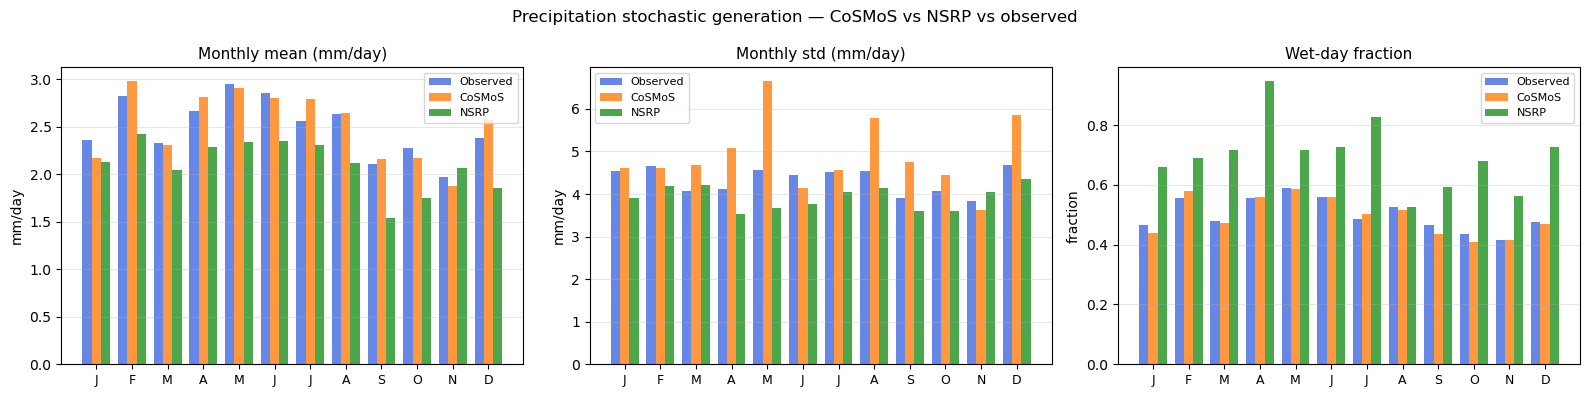

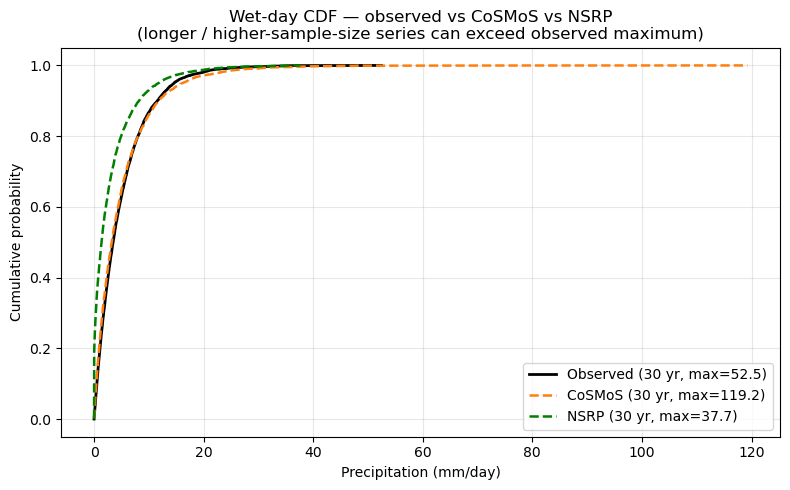

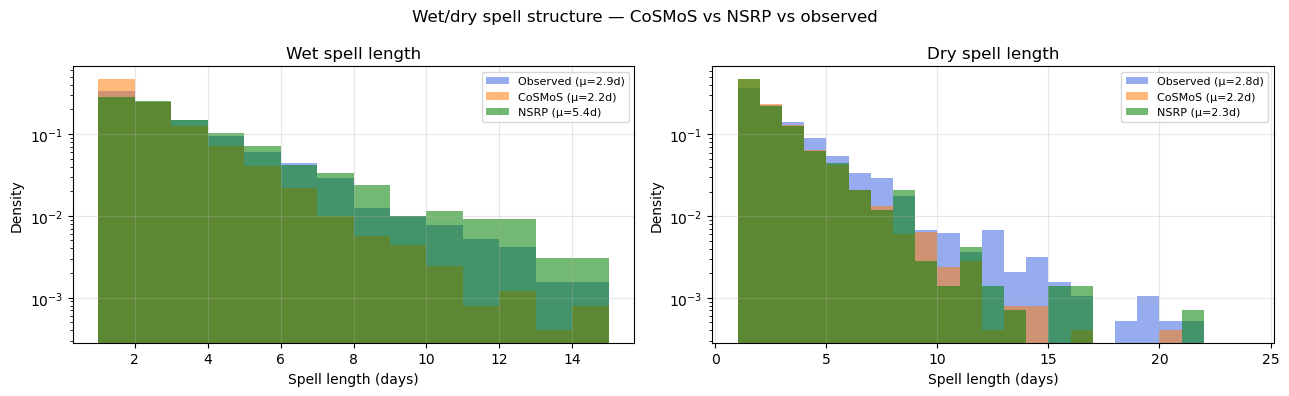


── Summary: CoSMoS vs NSRP — precipitation ─────────────────
Statistic                      Observed     CoSMoS       NSRP
--------------------------------------------------------------
Annual mean (mm/day)               2.49       2.52       2.10
Annual std (mm/day)                4.35       4.98       3.94
Wet-day fraction                   0.50       0.49       0.70
Max daily (mm/day)                 52.5      119.2       37.7
Mean wet spell (days)               2.9        2.2        5.4
Mean dry spell (days)               2.8        2.2        2.3


In [16]:
import warnings

months = list(range(1, 13))
lbl    = ["J","F","M","A","M","J","J","A","S","O","N","D"]
x      = np.arange(12)

# ═══════════════════════════════════════════════════════════════════
# A. CoSMoS fitted to precipitation (P_obs)
# ═══════════════════════════════════════════════════════════════════
# analyze_ts handles p0 (zero probability) automatically from the data.
print("Fitting CoSMoS seasonal model to precipitation ...")
ts_stats_p = analyze_ts(P_obs, dist='gengamma', acs_id='weibull')
stats_df_p = report_ts(ts_stats_p)
print("Done.\n")
print("CoSMoS seasonal model — precipitation:")
print(stats_df_p[['dist', 'mean', 'sd', 'p0', 'acs.l.2']].to_string())

# CoSMoS 30-year realisation
sim_cosmos = simulate_ts(ts_stats_p, from_date="1990-01-01", to_date="2019-12-31")
sim_cosmos_s = sim_cosmos.set_index("date")["value"].clip(lower=0)

# ═══════════════════════════════════════════════════════════════════
# B. NSRP 100-year simulation — use first 30 years for comparison
# ═══════════════════════════════════════════════════════════════════
sim_nsrp = sim_s.loc[sim_s.index.year <= sim_s.index.year[0] + 29]

# ── Helper: spell length distribution ────────────────────────────
def _spells(arr_values, is_wet):
    arr = np.asarray(arr_values) > 0
    if not is_wet:
        arr = ~arr
    runs, count = [], 0
    for v in arr:
        if v:
            count += 1
        else:
            if count > 0:
                runs.append(count)
            count = 0
    if count > 0:
        runs.append(count)
    return np.array(runs) if runs else np.array([0])

# ── Monthly statistics ────────────────────────────────────────────
obs_mean = np.array([P_obs[P_obs.index.month == m].mean() for m in months])
obs_std  = np.array([P_obs[P_obs.index.month == m].std()  for m in months])
obs_wet  = np.array([(P_obs[P_obs.index.month == m] > 0).mean() for m in months])

cos_mean = np.array([sim_cosmos_s[sim_cosmos_s.index.month == m].mean() for m in months])
cos_std  = np.array([sim_cosmos_s[sim_cosmos_s.index.month == m].std()  for m in months])
cos_wet  = np.array([(sim_cosmos_s[sim_cosmos_s.index.month == m] > 0).mean() for m in months])

nsp_mean = np.array([sim_nsrp[sim_nsrp.index.month == m].mean() for m in months])
nsp_std  = np.array([sim_nsrp[sim_nsrp.index.month == m].std()  for m in months])
nsp_wet  = np.array([(sim_nsrp[sim_nsrp.index.month == m] > 0).mean() for m in months])

# ── Figure 1: monthly statistics — 3 side-by-side panels ─────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
w = 0.26
for ax, obs_v, cos_v, nsp_v, title, ylabel in zip(
    axes,
    [obs_mean, obs_std, obs_wet],
    [cos_mean, cos_std, cos_wet],
    [nsp_mean, nsp_std, nsp_wet],
    ["Monthly mean (mm/day)", "Monthly std (mm/day)", "Wet-day fraction"],
    ["mm/day", "mm/day", "fraction"],
):
    ax.bar(x - w, obs_v, w, color="royalblue", alpha=0.8, label="Observed")
    ax.bar(x,     cos_v, w, color="C1",        alpha=0.8, label="CoSMoS")
    ax.bar(x + w, nsp_v, w, color="green",     alpha=0.7, label="NSRP")
    ax.set_xticks(x); ax.set_xticklabels(lbl, fontsize=9)
    ax.set_ylabel(ylabel); ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
if axes[2].get_ylim()[1] > 1.1:
    axes[2].set_ylim(0, 1.05)

plt.suptitle("Precipitation stochastic generation — CoSMoS vs NSRP vs observed", fontsize=12)
plt.tight_layout(); plt.show()

# ── Figure 2: wet-day CDF ─────────────────────────────────────────
obs_w  = np.sort(P_obs[P_obs > 0].values)
cos_w  = np.sort(sim_cosmos_s[sim_cosmos_s > 0].values)
nsp_w  = np.sort(sim_nsrp[sim_nsrp > 0].values)
p_obs  = np.arange(1, len(obs_w)+1) / (len(obs_w)+1)
p_cos  = np.arange(1, len(cos_w)+1) / (len(cos_w)+1)
p_nsp  = np.arange(1, len(nsp_w)+1) / (len(nsp_w)+1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(obs_w, p_obs, "k-",  lw=2,   label=f"Observed (30 yr, max={obs_w.max():.1f})")
ax.plot(cos_w, p_cos, "C1--", lw=1.8, label=f"CoSMoS (30 yr, max={cos_w.max():.1f})")
ax.plot(nsp_w, p_nsp, "g--",  lw=1.8, label=f"NSRP (30 yr, max={nsp_w.max():.1f})")
ax.set_xlabel("Precipitation (mm/day)"); ax.set_ylabel("Cumulative probability")
ax.set_title("Wet-day CDF — observed vs CoSMoS vs NSRP\n"
             "(longer / higher-sample-size series can exceed observed maximum)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── Figure 3: wet/dry spell distributions ────────────────────────
obs_ws = _spells(P_obs.values, True);       obs_ds = _spells(P_obs.values, False)
cos_ws = _spells(sim_cosmos_s.values, True); cos_ds = _spells(sim_cosmos_s.values, False)
nsp_ws = _spells(sim_nsrp.values, True);    nsp_ds = _spells(sim_nsrp.values, False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ws_data, ds_data, bins, title in [
    (axes[0], [obs_ws, cos_ws, nsp_ws], None, range(1, 16), "Wet spell length"),
    (axes[1], None, [obs_ds, cos_ds, nsp_ds], range(1, 25), "Dry spell length"),
]:
    series = ws_data if ws_data is not None else ds_data
    labels = ["Observed", "CoSMoS", "NSRP"]
    colors = ["royalblue", "C1", "green"]
    means  = [s.mean() for s in series]
    for data, lbl_n, col, mu in zip(series, labels, colors, means):
        ax.hist(data, bins=bins, density=True, alpha=0.55, color=col, label=f"{lbl_n} (μ={mu:.1f}d)")
    ax.set_xlabel("Spell length (days)"); ax.set_ylabel("Density")
    ax.set_title(title); ax.set_yscale("log"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Wet/dry spell structure — CoSMoS vs NSRP vs observed", fontsize=12)
plt.tight_layout(); plt.show()

# ── Summary table ─────────────────────────────────────────────────
print("\n── Summary: CoSMoS vs NSRP — precipitation ─────────────────")
print(f"{'Statistic':<28} {'Observed':>10} {'CoSMoS':>10} {'NSRP':>10}")
print("-" * 62)
print(f"{'Annual mean (mm/day)':<28} {P_obs.mean():10.2f} {sim_cosmos_s.mean():10.2f} {sim_nsrp.mean():10.2f}")
print(f"{'Annual std (mm/day)':<28} {P_obs.std():10.2f} {sim_cosmos_s.std():10.2f} {sim_nsrp.std():10.2f}")
print(f"{'Wet-day fraction':<28} {(P_obs>0).mean():10.2f} {(sim_cosmos_s>0).mean():10.2f} {(sim_nsrp>0).mean():10.2f}")
print(f"{'Max daily (mm/day)':<28} {P_obs.max():10.1f} {sim_cosmos_s.max():10.1f} {sim_nsrp.max():10.1f}")
print(f"{'Mean wet spell (days)':<28} {obs_ws.mean():10.1f} {cos_ws.mean():10.1f} {nsp_ws.mean():10.1f}")
print(f"{'Mean dry spell (days)':<28} {obs_ds.mean():10.1f} {cos_ds.mean():10.1f} {nsp_ds.mean():10.1f}")